# 02 — MBA-Relevant Occupation Analysis

Narrowing the full H-1B/PERM dataset down to roles an MBA graduate can realistically target,
and starting to answer the recruiting-strategy questions: which employers, which functions,
which locations give an international MBA the best odds of sponsorship.

**Important caveat**: neither disclosure file includes a minimum-degree-required field (PERM's
public extract only has `OCCUPATION_TYPE`: Professional / Non-professional / College-University
Teacher — it drops the more detailed education fields DOL collects internally). So "MBA-relevant"
here is a SOC-code + title heuristic (see `src/mba_occupations.py`), not a hard filter on actual
degree requirements. Treat tier splits as directional, not exact.

Data now spans full FY2025 plus FY2026 through Q3, so we can start asking not just "who
sponsors MBA-relevant roles" but "is that pool growing or shrinking" — relevant given how fast
the sponsorship landscape has been moving.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402
from mba_occupations import classify_mba_relevance  # noqa: E402
from employer_canonicalization import add_canonical_employer, build_canonical_map  # noqa: E402
from employer_brand_rollup import apply_brand_rollup  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"

In [2]:
lca = load_lca()
perm = load_perm()

lca["MBA_TIER"] = classify_mba_relevance(lca["SOC_CODE"], lca["SOC_TITLE"])
perm["MBA_TIER"] = classify_mba_relevance(perm["PWD_SOC_CODE"], perm["PWD_SOC_TITLE"])

employer_mapping = build_canonical_map(lca["EMPLOYER_NAME"], perm["EMP_BUSINESS_NAME"])
lca = add_canonical_employer(lca, "EMPLOYER_NAME", "EMPLOYER_CANONICAL", mapping=employer_mapping)
perm = add_canonical_employer(perm, "EMP_BUSINESS_NAME", "EMPLOYER_CANONICAL", mapping=employer_mapping)
lca["EMPLOYER_CANONICAL"] = apply_brand_rollup(lca["EMPLOYER_CANONICAL"])
perm["EMPLOYER_CANONICAL"] = apply_brand_rollup(perm["EMPLOYER_CANONICAL"])

## How much of the market is actually MBA-relevant?

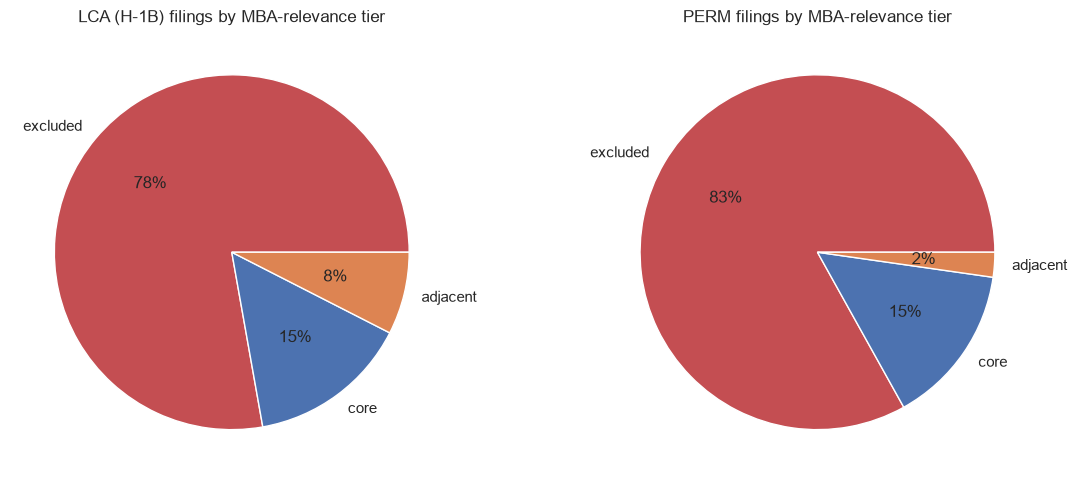

LCA:
 MBA_TIER
excluded    796380
core        150369
adjacent     76890
Name: count, dtype: int64 

PERM:
 MBA_TIER
excluded    215601
core         38029
adjacent      5859
Name: count, dtype: int64


In [3]:
lca_tier_counts = lca["MBA_TIER"].value_counts()
perm_tier_counts = perm["MBA_TIER"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_tier_counts.plot.pie(ax=axes[0], autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0", "#DD8452"])
axes[0].set_title("LCA (H-1B) filings by MBA-relevance tier")
perm_tier_counts.plot.pie(ax=axes[1], autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0", "#DD8452"])
axes[1].set_title("PERM filings by MBA-relevance tier")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_tier_share.png", dpi=150)
plt.show()

print("LCA:\n", lca_tier_counts, "\n")
print("PERM:\n", perm_tier_counts)

In [4]:
lca_mba = lca[lca["MBA_TIER"] != "excluded"].copy()
perm_mba = perm[perm["MBA_TIER"] != "excluded"].copy()
print(f"MBA-relevant LCA filings: {len(lca_mba):,} ({len(lca_mba) / len(lca):.1%} of all)")
print(f"MBA-relevant PERM filings: {len(perm_mba):,} ({len(perm_mba) / len(perm):.1%} of all)")

MBA-relevant LCA filings: 227,259 (22.2% of all)
MBA-relevant PERM filings: 43,888 (16.9% of all)


## Is the MBA-relevant pool growing or shrinking? FY2025 vs FY2026 (Q1-Q3 only, for a fair
comparison against FY2026's partial year)


LCA (H-1B) — MBA-tier filings, FY2025 vs FY2026 (Q1-Q3):
MBA_TIER      core  adjacent  excluded
FISCAL_YEAR                           
2025         67995     36386    365068
2026         66781     31578    339137
  core: -1.8% YoY
  adjacent: -13.2% YoY



PERM — MBA-tier filings, FY2025 vs FY2026 (Q1-Q3):
MBA_TIER      core  adjacent  excluded
FISCAL_YEAR                           
2025         13830      2172     85001
2026         17207      2618     92725
  core: +24.4% YoY
  adjacent: +20.5% YoY


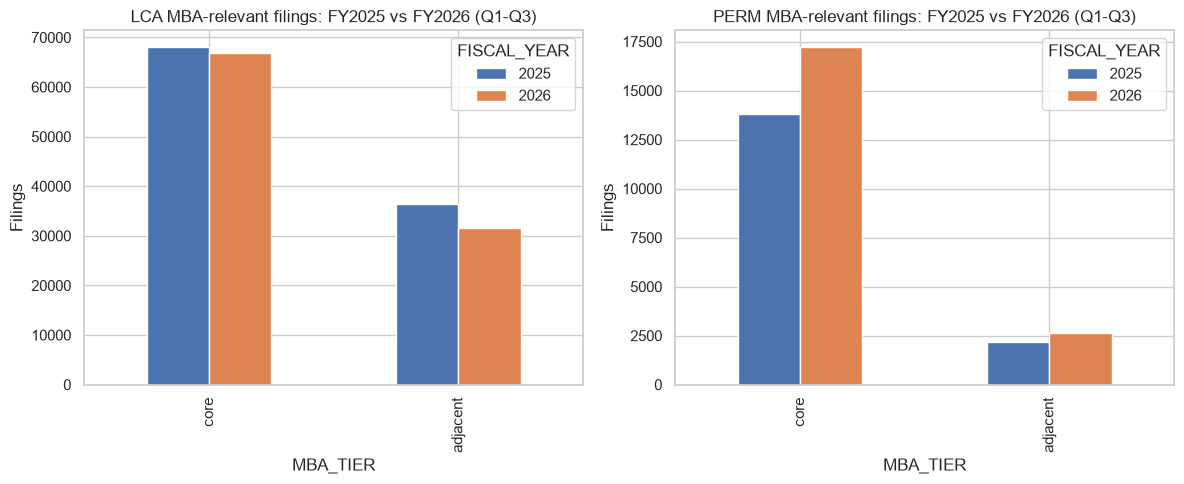

In [5]:
def mba_yoy_by_quarter(df, label):
    q13 = df[df["FISCAL_QUARTER"] <= 3]
    g = q13.groupby(["FISCAL_YEAR", "MBA_TIER"]).size().unstack(fill_value=0)
    g = g.reindex(columns=["core", "adjacent", "excluded"], fill_value=0)
    print(f"\n{label} — MBA-tier filings, FY2025 vs FY2026 (Q1-Q3):")
    print(g)
    for tier in ["core", "adjacent"]:
        if 2025 in g.index and 2026 in g.index and g.loc[2025, tier] > 0:
            pct = (g.loc[2026, tier] / g.loc[2025, tier] - 1) * 100
            print(f"  {tier}: {pct:+.1f}% YoY")
    return g


lca_mba_yoy = mba_yoy_by_quarter(lca, "LCA (H-1B)")
perm_mba_yoy = mba_yoy_by_quarter(perm, "PERM")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_mba_yoy[["core", "adjacent"]].T.plot.bar(ax=axes[0])
axes[0].set_title("LCA MBA-relevant filings: FY2025 vs FY2026 (Q1-Q3)")
axes[0].set_ylabel("Filings")
perm_mba_yoy[["core", "adjacent"]].T.plot.bar(ax=axes[1])
axes[1].set_title("PERM MBA-relevant filings: FY2025 vs FY2026 (Q1-Q3)")
axes[1].set_ylabel("Filings")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_yoy.png", dpi=150)
plt.show()

## Certification rate: does it differ by tier?

If core/adjacent roles get certified at a similar (or better) rate than the broader market,
that's reassuring — it means the bottleneck for MBAs isn't the process, it's finding
employers who file for these roles at all.

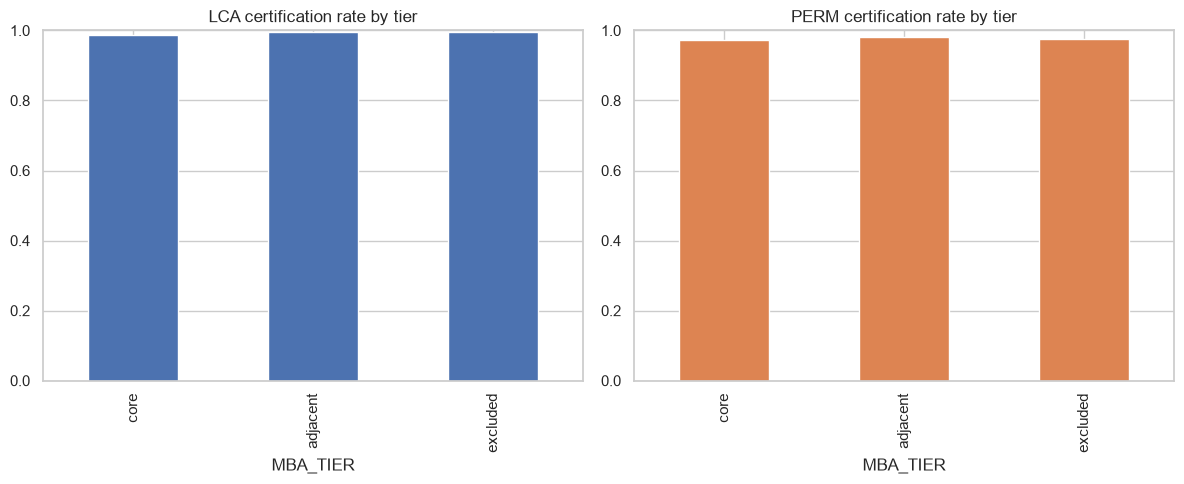

In [6]:
def cert_rate_by_tier(df, decided_statuses, denied_status="Denied"):
    decided = df[df["CASE_STATUS"].isin(decided_statuses)]
    return decided.groupby("MBA_TIER")["CASE_STATUS"].apply(lambda s: (s != denied_status).mean())


lca_cert_by_tier = cert_rate_by_tier(lca, ["Certified", "Certified - Withdrawn", "Denied"])
perm_cert_by_tier = cert_rate_by_tier(perm, ["Certified", "Certified - Expired", "Denied"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lca_cert_by_tier.reindex(["core", "adjacent", "excluded"]).plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("LCA certification rate by tier")
axes[0].set_ylim(0, 1)
perm_cert_by_tier.reindex(["core", "adjacent", "excluded"]).plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("PERM certification rate by tier")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_cert_rate_by_tier.png", dpi=150)
plt.show()

## Real hiring signal: is a filing actually a new opportunity?

A question worth answering directly: do employers file H-1Bs/PERMs just to "test" something,
and should we exclude withdrawn/denied cases to get a real read on hiring? Denials/withdrawals
are small and safe to exclude (already implicit in the certification-rate calc above), but
that's not actually the biggest gap between "a filing exists" and "there's a real open seat."

For LCA: `NEW_EMPLOYMENT` counts new-position slots on a filing, separate from
`CONTINUED_EMPLOYMENT` (extension for someone already there) and `CHANGE_EMPLOYER` (an H-1B
transfer for someone already employed elsewhere on H-1B). Only `NEW_EMPLOYMENT > 0` filings
represent a position genuinely open to an outside candidate.

In [7]:
lca_mba["IS_NEW_POSITION"] = lca_mba["NEW_EMPLOYMENT"].fillna(0) > 0
new_position_share = lca_mba["IS_NEW_POSITION"].mean()
print(f"Share of MBA-relevant LCA filings that include a new position: {new_position_share:.1%}")
print("(the rest are pure extensions/amendments/transfers of people already employed there)")

Share of MBA-relevant LCA filings that include a new position: 38.5%
(the rest are pure extensions/amendments/transfers of people already employed there)


For PERM, the more important nuance is `OTHER_REQ_IS_FW_CURRENTLY_WRK`: whether the foreign
worker is already employed by that employer in that job at filing time. A PERM case with `Y`
here is a green-card *conversion* for an existing H-1B employee, not an offer to an outside
candidate — which reframes what PERM data can honestly promise a job-searching student.

In [8]:
perm_mba_working_flag = perm_mba["OTHER_REQ_IS_FW_CURRENTLY_WRK"].value_counts(normalize=True, dropna=False)
print(perm_mba_working_flag)
print(f"\nShare of MBA-relevant PERM filings for someone NOT already at that employer: "
      f"{perm_mba_working_flag.get('N', 0):.1%}")

OTHER_REQ_IS_FW_CURRENTLY_WRK
Y    0.858435
N    0.141565
Name: proportion, dtype: float64

Share of MBA-relevant PERM filings for someone NOT already at that employer: 14.2%


**Bottom line for the dashboard**: treat `NEW_EMPLOYMENT > 0` (LCA) and
`OTHER_REQ_IS_FW_CURRENTLY_WRK == 'N'` (PERM) as the "real new opportunity" filters, not
`CASE_STATUS`. Full employer-level breakdowns of both live in notebook 04.

## Which functions within "core" and "adjacent" see the most volume?

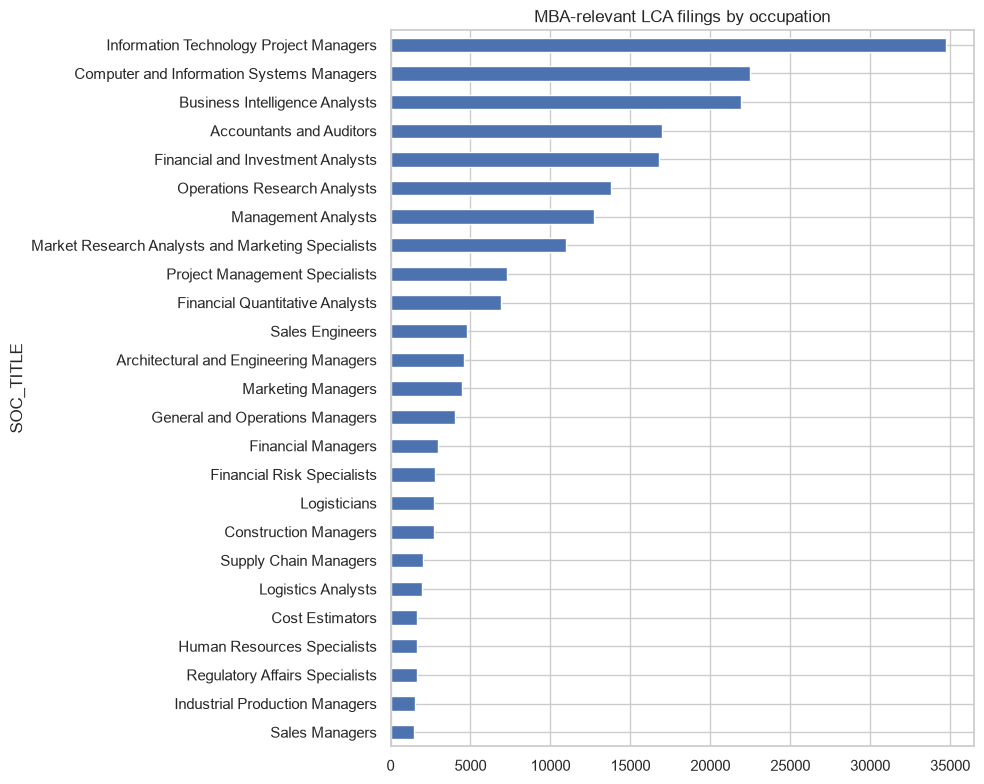

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
lca_mba["SOC_TITLE"].value_counts().head(25).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("MBA-relevant LCA filings by occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_occupations_lca.png", dpi=150)
plt.show()

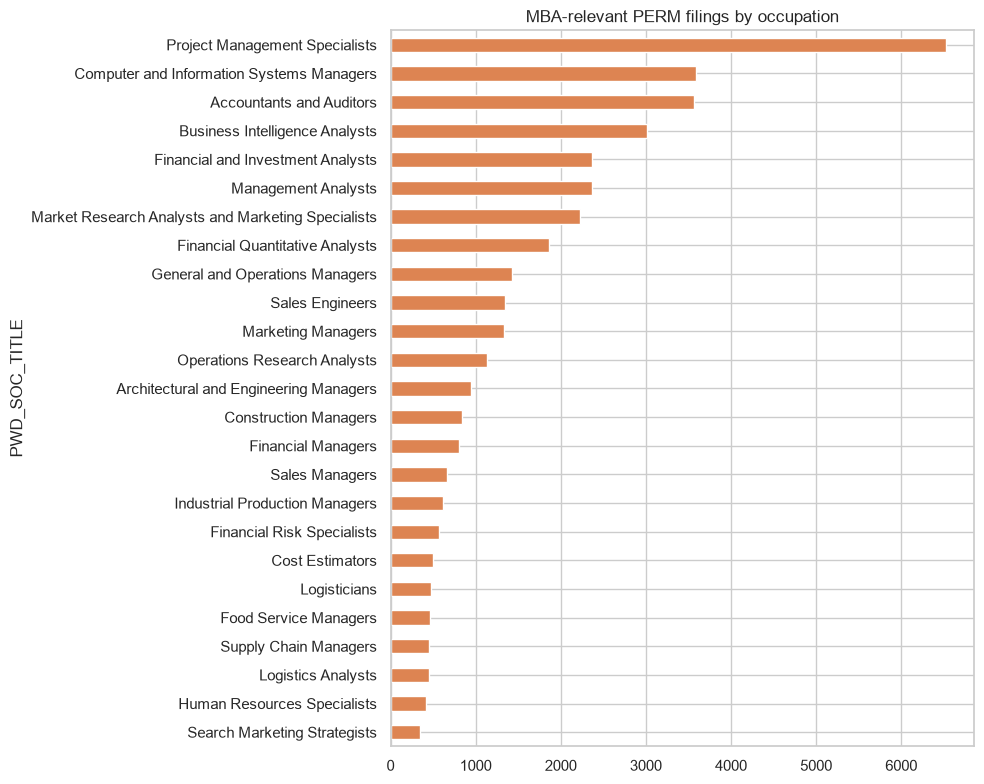

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
perm_mba["PWD_SOC_TITLE"].value_counts().head(25).sort_values().plot.barh(ax=ax, color="#DD8452")
ax.set_title("MBA-relevant PERM filings by occupation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_occupations_perm.png", dpi=150)
plt.show()

## Top employers sponsoring MBA-relevant roles

This is the recruiting-strategy payload: which companies are actually filing for business/
management-track roles (as opposed to being a huge H-1B filer purely on the engineering side).

In [11]:
top_employers_lca_mba = lca_mba["EMPLOYER_CANONICAL"].value_counts().head(30)
top_employers_lca_mba

EMPLOYER_CANONICAL
Amazon                                    12866
Ernst & Young U.S. LLP                     9253
Deloitte                                   5398
INFOSYS LIMITED                            3280
Goldman Sachs                              2619
Google LLC                                 2377
Microsoft Corporation                      2123
JPMorgan Chase & Co.                       2109
Apple Inc.                                 1994
Meta Platforms, Inc                        1706
WAL-MART ASSOCIATES, INC.                  1455
PwC                                        1345
COGNIZANT TECHNOLOGY SOLUTIONS US CORP     1318
Citigroup                                  1311
HCL                                        1284
Tesla, Inc.                                1123
Boston Consulting Group, Inc.              1072
Accenture LLP                              1037
Morgan Stanley                              970
Bank of America                             897
TATA CONSULTANCY SERV

In [12]:
top_employers_perm_mba = perm_mba["EMPLOYER_CANONICAL"].value_counts().head(30)
top_employers_perm_mba

EMPLOYER_CANONICAL
Microsoft Corporation                     780
Ernst & Young U.S. LLP                    575
Deloitte                                  551
Goldman Sachs                             465
MCKINSEY & COMPANY, INC. UNITED STATES    459
JPMorgan Chase & Co.                      373
Boston Consulting Group, Inc.             369
Citigroup                                 318
WAL-MART ASSOCIATES, INC.                 307
Accenture LLP                             302
PwC                                       276
TATA CONSULTANCY SERVICES LIMITED         258
Salesforce, Inc.                          239
Uber Technologies, Inc.                   216
Citadel                                   168
Tesla, Inc.                               166
Bank of America                           163
Cisco Systems, Inc.                       156
ByteDance Inc.                            155
FMR LLC                                   151
Morgan Stanley                            149
Adobe Inc.     

### "MBA-focused" employers: high share of MBA-relevant filings, not just high volume

A employer with 5 total filings, all core-MBA roles, is a better lead than one with 500
filings where only 2% are business-track. Rank by volume *and* mix.

In [13]:
def employer_mba_mix(df, employer_col, min_filings=10):
    g = df.groupby(employer_col)["MBA_TIER"].agg(
        total="count",
        mba_relevant=lambda s: (s != "excluded").sum(),
    )
    g["mba_share"] = g["mba_relevant"] / g["total"]
    return g[g["total"] >= min_filings].sort_values(["mba_share", "total"], ascending=False)


lca_employer_mix = employer_mba_mix(lca, "EMPLOYER_CANONICAL")
lca_employer_mix.head(25)

,total,mba_relevant,mba_share
EMPLOYER_CANONICAL,,,
"MANHATTAN ASSOCIATES, INC.",197,197,1.0
"SCOTIA CAPITAL (USA), INC.",101,101,1.0
"Standish Management US, LLC",92,92,1.0
Ernst & Young LLP (EY GUAM),67,67,1.0
The Siegfried Group LLP,59,59,1.0
"Houlihan Lokey Financial Advisors, Inc.",57,57,1.0
"The Smile Mission South Miami, PLLC",41,41,1.0
Macquarie America Holdings Inc.,35,35,1.0
"Alvarez & Marsal Consumer and Retail Group, LLC",34,34,1.0


In [14]:
perm_employer_mix = employer_mba_mix(perm, "EMPLOYER_CANONICAL")
perm_employer_mix.head(25)

,total,mba_relevant,mba_share
EMPLOYER_CANONICAL,,,
"BDO USA, P.C. (FKA BDO USA, LLP)",47,47,1.000000
EVERCORE PARTNERS SERVICES EAST LLC,34,34,1.000000
SQUAREPOINT SERVICES US LLC,26,26,1.000000
"BDO USA, P.C.",21,21,1.000000
Macias Gini & O'Connell LLP,17,17,1.000000
The Siegfried Group LLP,15,15,1.000000
Spike Inc.,14,14,1.000000
"Bayview Asset Management, LLC",13,13,1.000000
Funaro & Co. PC,13,13,1.000000


## Wage premium for MBA-relevant roles

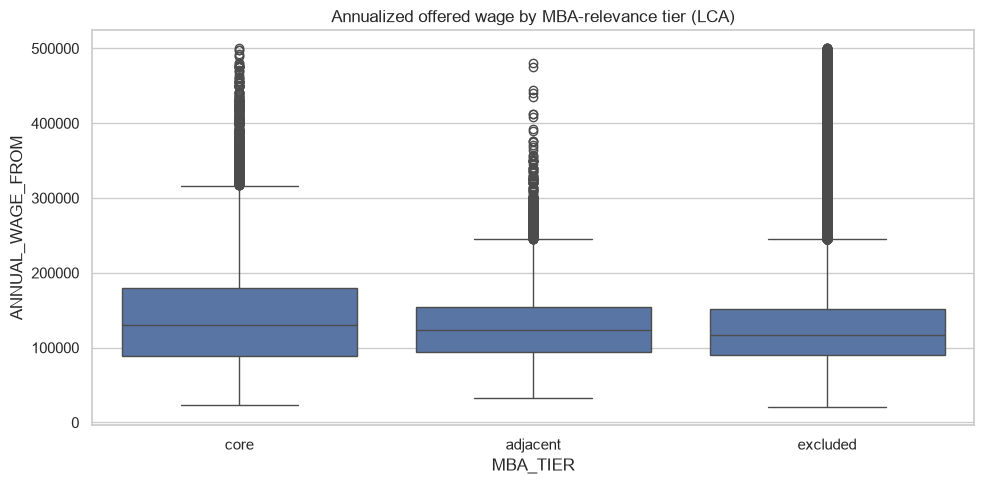

,count,mean,std,min,25%,50%,75%,max
MBA_TIER,,,,,,,,
adjacent,45180.0,129323.269554,43875.833596,33030.0,94682.0,124259.0,155000.00,480000.00
core,83112.0,140512.104335,64654.474993,24000.0,88483.0,130000.0,180003.65,499999.00
excluded,454999.0,127046.724050,52379.903665,20280.0,90002.0,117000.0,152100.00,499999.92


In [15]:
lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])
lca_wage = lca[(lca["ANNUAL_WAGE_FROM"] > 20_000) & (lca["ANNUAL_WAGE_FROM"] < 500_000)]

fig, ax = plt.subplots()
sns.boxplot(data=lca_wage, x="MBA_TIER", y="ANNUAL_WAGE_FROM", order=["core", "adjacent", "excluded"], ax=ax)
ax.set_title("Annualized offered wage by MBA-relevance tier (LCA)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_wage_by_tier.png", dpi=150)
plt.show()

lca_wage.groupby("MBA_TIER")["ANNUAL_WAGE_FROM"].describe()

## Geographic concentration of MBA-relevant sponsorship

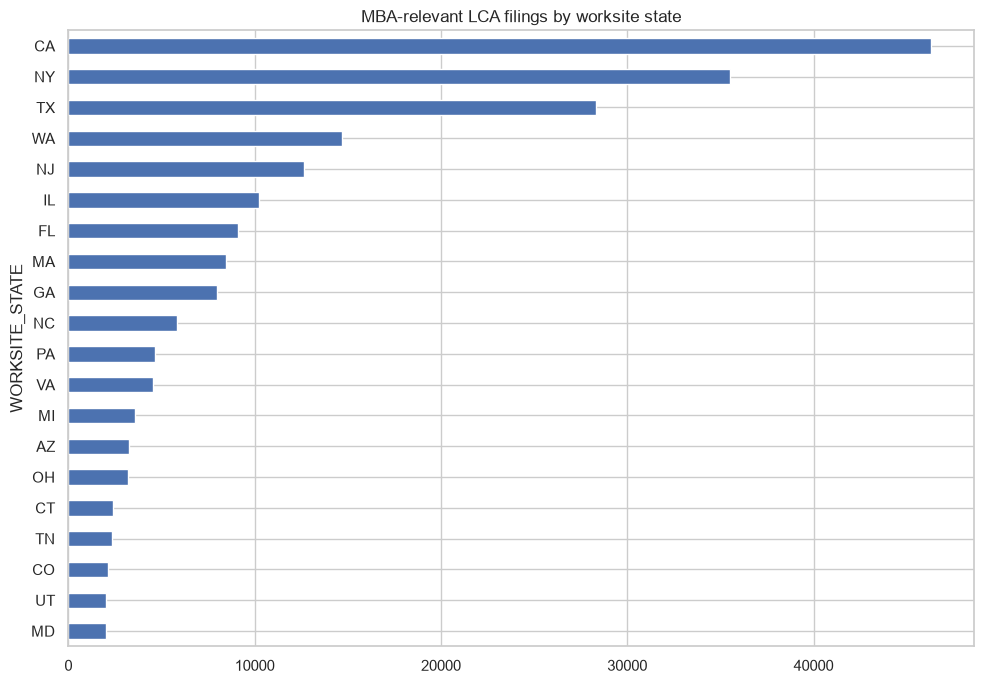

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
lca_mba["WORKSITE_STATE"].value_counts().head(20).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("MBA-relevant LCA filings by worksite state")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_mba_states.png", dpi=150)
plt.show()

## Save dashboard-ready aggregates

In [17]:
lca_employer_mix.reset_index().to_csv(PROCESSED_DIR / "lca_employer_mba_mix.csv", index=False)
perm_employer_mix.reset_index().to_csv(PROCESSED_DIR / "perm_employer_mba_mix.csv", index=False)
lca_mba["SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_mba_occupations.csv")
perm_mba["PWD_SOC_TITLE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "perm_mba_occupations.csv")
lca_mba["WORKSITE_STATE"].value_counts().rename("filings").to_csv(PROCESSED_DIR / "lca_mba_states.csv")

print("Saved MBA-focused aggregates to", PROCESSED_DIR)

Saved MBA-focused aggregates to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Where the rest of the analysis lives

- **Notebook 03** — industry (NAICS sector) rollups and geography (state-level, with county
  granularity available for a future drill-down), plus wage-level (I-IV) mix as a proxy for the
  seniority a role expects, since we have no applicant-experience field.
- **Notebook 04** — the full employer leaderboard (volume, mix, certification rate, new-position
  share, size/risk flags) and the LCA↔PERM employer match, showing who actually carries people
  from H-1B through to green card sponsorship.
- **Notebook 05** — a flexible keyword-based occupation search (`src/occupation_search.py`) that
  isn't boxed into the core/adjacent/excluded tiers here, run end-to-end for the original
  finance/risk/fintech persona plus two other backgrounds, to confirm the tooling generalizes.

Still open: a manually-curated brand alias list for the top employers (Amazon Web Services vs.
Amazon.com Services LLC are legitimately separate legal entities but the same brand — see
`src/employer_canonicalization.py`), and a better MBA-relevance signal than SOC/title regex if
a cleaner minimum-education proxy (e.g. O*NET's typical-education-by-SOC lookup) turns out to
be worth the integration effort.